In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df=pd.read_csv(r"C:\Users\Marco A RL\Desktop\PROYECTOSVSCODE\crime-analysis\Crimes_-_2001_to_Present_20260413.csv")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8530775 entries, 0 to 8530774
Data columns (total 22 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Case Number           str    
 2   Date                  str    
 3   Block                 str    
 4   IUCR                  str    
 5   Primary Type          str    
 6   Description           str    
 7   Location Description  str    
 8   Arrest                bool   
 9   Domestic              bool   
 10  Beat                  int64  
 11  District              float64
 12  Ward                  float64
 13  Community Area        float64
 14  FBI Code              str    
 15  X Coordinate          float64
 16  Y Coordinate          float64
 17  Year                  int64  
 18  Updated On            str    
 19  Latitude              float64
 20  Longitude             float64
 21  Location              str    
dtypes: bool(2), float64(7), int64(3), str(10)
memory usag

In [7]:
df["Primary Type"].value_counts().head(10)

Primary Type
THEFT                  1812139
BATTERY                1553778
CRIMINAL DAMAGE         969648
NARCOTICS               766873
ASSAULT                 573569
OTHER OFFENSE           532864
BURGLARY                450895
MOTOR VEHICLE THEFT     439147
DECEPTIVE PRACTICE      395441
ROBBERY                 316726
Name: count, dtype: int64

C:\Users\Marco A RL\AppData\Local\Temp\ipykernel_7932\2811432198.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"]=pd.to_datetime(df["Date"])


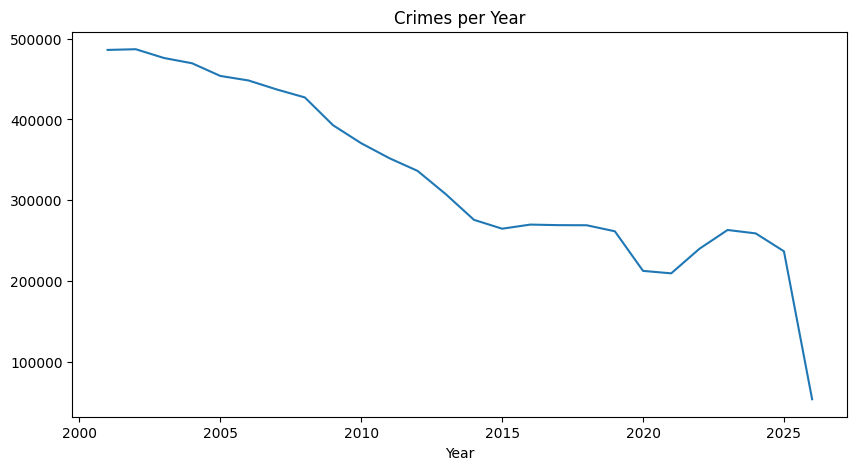

In [8]:
df["Date"]=pd.to_datetime(df["Date"])
df["Year"]=df["Date"].dt.year

crimes_per_year = df["Year"].value_counts().sort_index()

crimes_per_year.plot(figsize=(10,5))
plt.title("Crimes per Year")
plt.show()

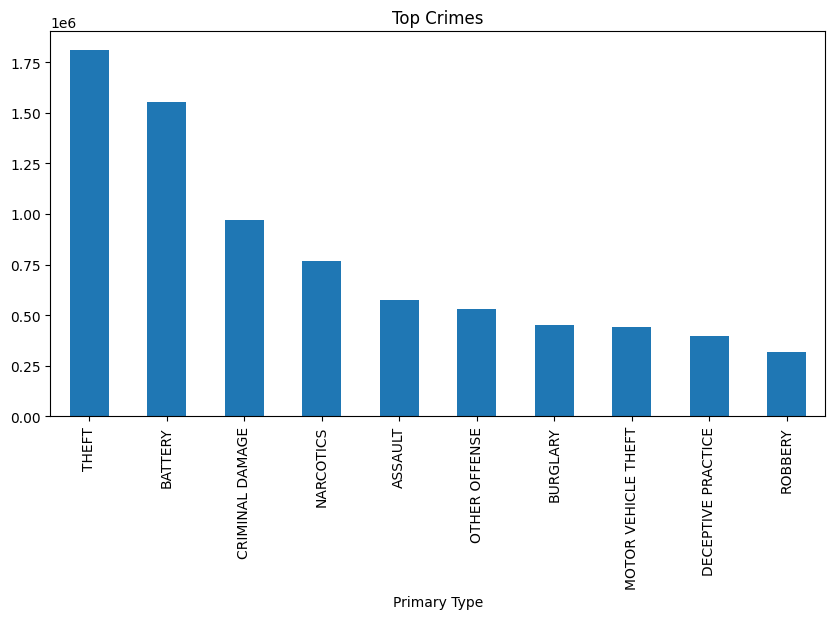

In [9]:
top_crimes=df["Primary Type"].value_counts().head(10)
top_crimes.plot(kind="bar",figsize=(10,5))
plt.title("Top Crimes")
plt.show()

In [ ]:
print(df["Year"].value_counts().idxmax())

2002


In [ ]:
df.isnull().sum().sort_values(ascending=False).head(10)

Ward                    614816
Community Area          613727
Location                 96289
Y Coordinate             96289
Longitude                96289
Latitude                 96289
X Coordinate             96289
Location Description     15870
District                    47
IUCR                         0
dtype: int64

In [23]:
df_clean=df.drop(columns=[
    "Case Number",
    "IUCR",
    "FBI Code",
    "Updated On"
])

In [34]:
df_clean["Date"]=pd.to_datetime(df_clean["Date"])
df_clean["Month"]=df_clean["Date"].dt.month
df_clean["Day"]=df_clean["Date"].dt.day
df_clean["Hour"]=df_clean["Date"].dt.hour

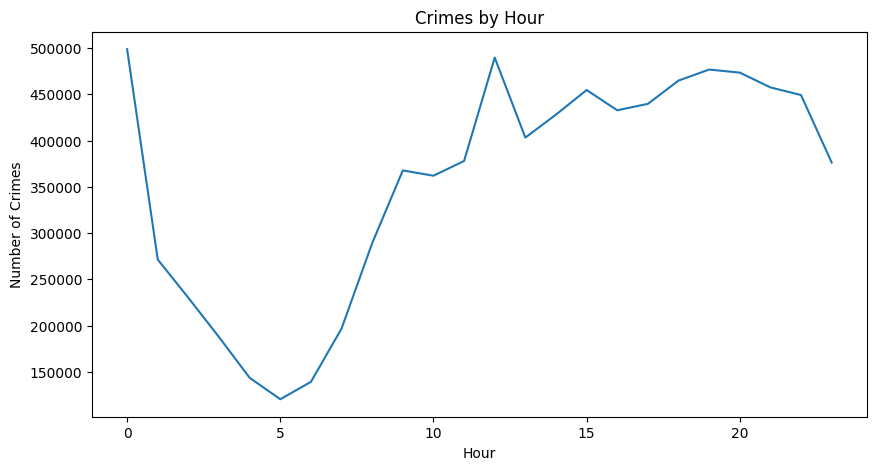

In [35]:
crime_by_hour=df_clean["Hour"].value_counts().sort_index()

crime_by_hour.plot(figsize=(10,5))
plt.title("Crimes by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Crimes")
plt.show()

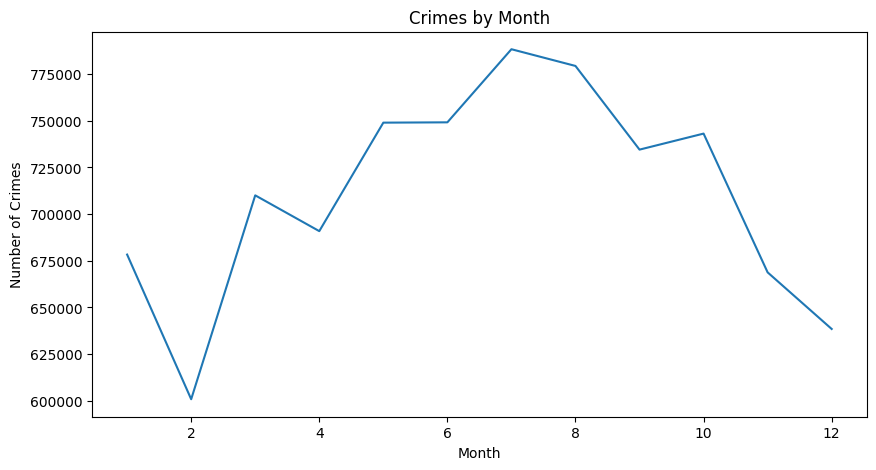

In [36]:
crime_by_month=df_clean["Month"].value_counts().sort_index()

crime_by_month.plot(figsize=(10,5))
plt.title("Crimes by Month")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.show()

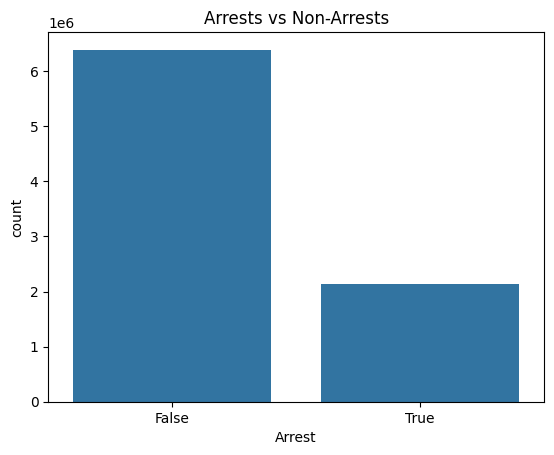

In [37]:
df_clean["Arrest"].value_counts()
sns.countplot(data=df_clean,x="Arrest")
plt.title("Arrests vs Non-Arrests")
plt.show()

In [ ]:
print(df_clean["Month"].value_counts().idxmax())
print(df_clean["Hour"].value_counts().idxmax())
print(df_clean["Arrest"].value_counts(normalize=True) * 100)

7
0
Arrest
False    74.887815
True     25.112185
Name: proportion, dtype: float64


In [47]:
df_clean[[
    "Latitude","Longitude"
    ]].head()

geo_df=df_clean.dropna(subset=["Latitude","Longitude"])

In [59]:
import folium as fm

crime_map=fm.Map(location=[41.8781,-87.6298],zoom_start=11)
sample=geo_df.sample(1000)

for i,r in sample.iterrows():
    fm.CircleMarker(
        location=[r["Latitude"],r["Longitude"]],
                  radius=3,
                  fill=False
    ).add_to(crime_map)
crime_map.save("crime_map.html")

In [61]:
df_clean.to_csv("crime_cleaned.csv", index=False)